# Heart Disease Analysis 

## Data Preperation and Review 

In [84]:
import pandas as pd
import numpy as nu
import matplotlib.pyplot as plt

In [85]:
Hrt =pd.read_csv(r"C:\Users\USER\Downloads\Dataset Heart Disease.csv")

In [86]:
print(Hrt.shape)

(1048, 13)


In [87]:
Data_Head = Hrt.head()
print(Data_Head)

   Unnamed: 0  age  sex  chest pain type  resting bps  cholesterol  \
0           0   40    1                2          140        289.0   
1           1   49    0                3          160        180.0   
2           2   37    1                2          130        283.0   
3           3   48    0                4          138        214.0   
4           4   54    1                3          150        195.0   

   fasting blood sugar  resting ecg  max heart rate  exercise angina  oldpeak  \
0                    0            0             172                0      0.0   
1                    0            0             156                0      1.0   
2                    0            1              98                0      0.0   
3                    0            0             108                1      1.5   
4                    0            0             122                0      0.0   

   ST slope  target  
0         1       0  
1         2       1  
2         1       0  
3   

In [88]:
info = Hrt.info()
print(info)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048 entries, 0 to 1047
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           1048 non-null   int64  
 1   age                  1048 non-null   int64  
 2   sex                  1048 non-null   int64  
 3   chest pain type      1048 non-null   int64  
 4   resting bps          1048 non-null   int64  
 5   cholesterol          1048 non-null   float64
 6   fasting blood sugar  1048 non-null   int64  
 7   resting ecg          1048 non-null   int64  
 8   max heart rate       1048 non-null   int64  
 9   exercise angina      1048 non-null   int64  
 10  oldpeak              1048 non-null   float64
 11  ST slope             1048 non-null   int64  
 12  target               1048 non-null   int64  
dtypes: float64(2), int64(11)
memory usage: 106.6 KB
None


In [89]:
view_data_details = Hrt.describe()
print(view_data_details)

        Unnamed: 0          age          sex  chest pain type  resting bps  \
count  1048.000000  1048.000000  1048.000000      1048.000000  1048.000000   
mean    390.841603    53.325382     0.734733         2.817748   132.613550   
std     307.916633     9.397822     0.441686         1.118649    17.367605   
min       0.000000    28.000000     0.000000         1.000000    92.000000   
25%     130.750000    46.000000     0.000000         2.000000   120.000000   
50%     262.000000    54.000000     1.000000         3.000000   130.000000   
75%     657.250000    60.000000     1.000000         4.000000   140.000000   
max    1189.000000    77.000000     1.000000         4.000000   200.000000   

       cholesterol  fasting blood sugar  resting ecg  max heart rate  \
count  1048.000000          1048.000000  1048.000000     1048.000000   
mean    245.172710             0.162214     0.606870      142.918893   
std      57.101359             0.368823     0.763313       24.427115   
min      

Target= Heart Disease(1)
Sex= Male(1), Female(0)

Remove unnecessary data 

In [90]:
Hrt = Hrt.drop(columns=['Unnamed: 0'])

In [91]:
DICT = {1:'Male',0:'Female'}
Hrt['sex'] =Hrt['sex'].replace(DICT).astype('category')
Hrt.head()

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,Male,2,140,289.0,0,0,172,0,0.0,1,0
1,49,Female,3,160,180.0,0,0,156,0,1.0,2,1
2,37,Male,2,130,283.0,0,1,98,0,0.0,1,0
3,48,Female,4,138,214.0,0,0,108,1,1.5,2,1
4,54,Male,3,150,195.0,0,0,122,0,0.0,1,0


In [130]:
Hrt['target']

0       0
1       1
2       0
3       1
4       0
       ..
1043    1
1044    1
1045    0
1046    0
1047    0
Name: target, Length: 1048, dtype: int64

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (213, 12) and arg 1 with shape (471, 12).

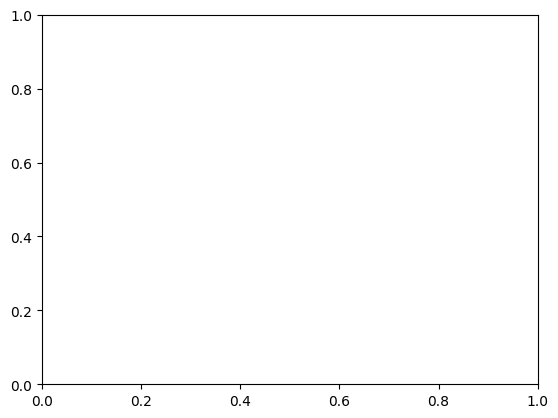

In [136]:
plt.bar( Hrt[(Hrt['age'] > 20) & (Hrt['age'] < 45)] , Hrt[(Hrt['chest pain type'] > 1) & (Hrt['chest pain type'] < 4)] )

<BarContainer object of 1048 artists>

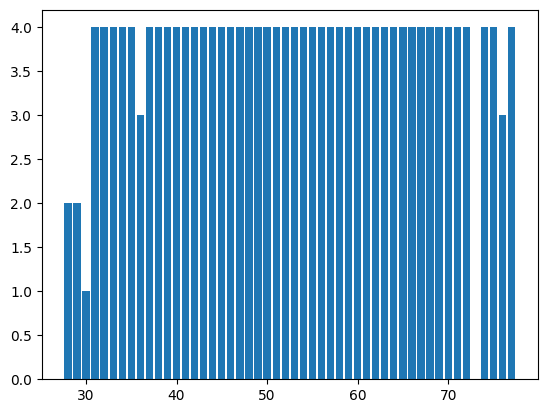

In [138]:
plt.bar(Hrt['age']  , Hrt['chest pain type'] )

In [139]:
plotCorrelationMatrix(Hrt, 8)

NameError: name 'plotCorrelationMatrix' is not defined

In [140]:
plt.cohere(Hrt)

TypeError: cohere() missing 1 required positional argument: 'y'

## Data Relations

### Grouping Data by common factors for insightful relational analysis 

### General Level of high chest pain 

In [93]:
High_CP = Hrt[Hrt['chest pain type'] >= 3]
High_CP

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
1,49,Female,3,160,180.0,0,0,156,0,1.0,2,1
3,48,Female,4,138,214.0,0,0,108,1,1.5,2,1
4,54,Male,3,150,195.0,0,0,122,0,0.0,1,0
5,39,Male,3,120,339.0,0,0,170,0,0.0,1,0
8,37,Male,4,140,207.0,0,0,130,1,1.5,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1040,60,Female,3,120,178.0,1,1,96,0,0.0,2,1
1042,64,Male,3,140,335.0,0,1,158,0,0.0,2,0
1043,68,Female,3,120,211.0,0,0,115,0,1.5,1,1
1044,44,Female,3,108,141.0,0,1,175,0,0.6,1,1


Text(0, 0.5, '')

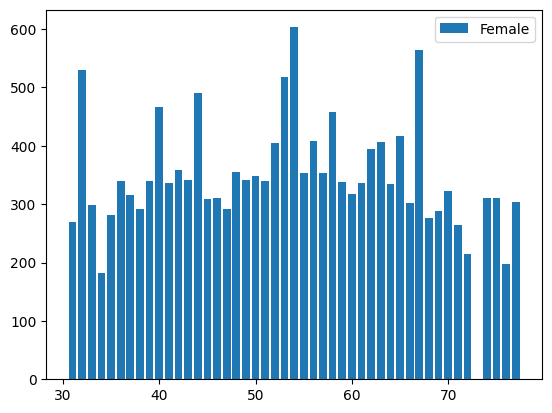

In [94]:
plt.bar(High_CP['age'] , High_CP['cholesterol'])
plt.legend(High_CP['sex'])
plt.xlabel('')
plt.ylabel('')

We can observe high values of max heart rate in 

In [95]:
Low_CP = Hrt[Hrt['chest pain type'] < 3]
Low_CP

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,Male,2,140,289.0,0,0,172,0,0.0,1,0
2,37,Male,2,130,283.0,0,1,98,0,0.0,1,0
6,45,Female,2,130,237.0,0,0,170,0,0.0,1,0
7,54,Male,2,110,208.0,0,0,142,0,0.0,1,0
9,48,Female,2,120,284.0,0,0,120,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1038,55,Female,2,135,250.0,0,0,161,0,1.4,1,1
1039,39,Male,1,118,219.0,0,1,140,0,1.2,1,0
1041,52,Male,1,108,233.0,1,1,147,0,0.1,2,1
1045,52,Male,1,128,255.0,0,1,161,1,0.0,2,0


### High Cholesterole levels 
High number of people with cholesterole level above the reaserched average of 170

In [96]:
High_Col = Hrt[Hrt['cholesterol'] > 170]
High_Col

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,Male,2,140,289.0,0,0,172,0,0.0,1,0
1,49,Female,3,160,180.0,0,0,156,0,1.0,2,1
2,37,Male,2,130,283.0,0,1,98,0,0.0,1,0
3,48,Female,4,138,214.0,0,0,108,1,1.5,2,1
4,54,Male,3,150,195.0,0,0,122,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1042,64,Male,3,140,335.0,0,1,158,0,0.0,2,0
1043,68,Female,3,120,211.0,0,0,115,0,1.5,1,1
1045,52,Male,1,128,255.0,0,1,161,1,0.0,2,0
1046,59,Male,4,160,273.0,0,0,125,0,0.0,2,0


### Age


#### Older than 50

In [97]:
Age_Old = Hrt[(Hrt['age'] > 50) ]
Age_Old

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
4,54,Male,3,150,195.0,0,0,122,0,0.0,1,0
7,54,Male,2,110,208.0,0,0,142,0,0.0,1,0
11,58,Male,2,136,164.0,0,1,99,1,2.0,2,1
15,54,Female,2,120,273.0,0,0,150,0,1.5,2,0
18,60,Male,4,100,248.0,0,0,125,0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1042,64,Male,3,140,335.0,0,1,158,0,0.0,2,0
1043,68,Female,3,120,211.0,0,0,115,0,1.5,1,1
1045,52,Male,1,128,255.0,0,1,161,1,0.0,2,0
1046,59,Male,4,160,273.0,0,0,125,0,0.0,2,0


<Axes: >

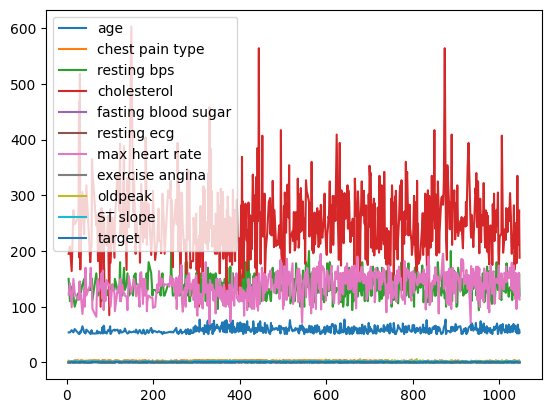

In [98]:
# High Heart Rate
Age_Old[Age_Old['max heart rate'] > 142]

Age_Old.plot()

In [99]:
# High Cholesterol
Age_Old[Age_Old['cholesterol'] > 170]

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
4,54,Male,3,150,195.0,0,0,122,0,0.0,1,0
7,54,Male,2,110,208.0,0,0,142,0,0.0,1,0
15,54,Female,2,120,273.0,0,0,150,0,1.5,2,0
18,60,Male,4,100,248.0,0,0,125,0,1.0,2,1
26,53,Male,4,124,260.0,0,1,112,1,3.0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1042,64,Male,3,140,335.0,0,1,158,0,0.0,2,0
1043,68,Female,3,120,211.0,0,0,115,0,1.5,1,1
1045,52,Male,1,128,255.0,0,1,161,1,0.0,2,0
1046,59,Male,4,160,273.0,0,0,125,0,0.0,2,0


In [100]:
# Normal/low Cholesterol
Age_Old[Age_Old['cholesterol'] < 170]

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
11,58,Male,2,136,164.0,0,1,99,1,2.0,2,1
31,56,Male,3,130,167.0,0,0,114,0,0.0,1,0
78,52,Male,2,140,100.0,0,0,138,1,0.0,1,0
85,66,Male,4,140,139.0,0,0,94,1,1.0,2,1
98,56,Male,4,120,85.0,0,0,140,0,0.0,1,0
138,54,Male,4,140,166.0,0,0,118,1,0.0,2,1
263,59,Male,4,130,126.0,0,0,125,0,0.0,2,1
276,51,Male,3,135,160.0,0,0,150,0,2.0,2,1
286,59,Male,4,140,169.0,0,0,140,0,0.0,1,0
300,56,Male,2,126,166.0,0,1,140,0,0.0,1,0


#### Youger than 50 

In [101]:
Age_Young = Hrt[(Hrt['age'] < 50) ]
Age_Young

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,Male,2,140,289.0,0,0,172,0,0.0,1,0
1,49,Female,3,160,180.0,0,0,156,0,1.0,2,1
2,37,Male,2,130,283.0,0,1,98,0,0.0,1,0
3,48,Female,4,138,214.0,0,0,108,1,1.5,2,1
5,39,Male,3,120,339.0,0,0,170,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1021,44,Male,3,140,235.0,0,0,180,0,0.0,2,1
1026,46,Male,2,101,197.0,1,1,156,0,0.0,2,1
1032,43,Male,1,115,303.0,0,1,181,0,1.2,1,1
1039,39,Male,1,118,219.0,0,1,140,0,1.2,1,0


In [102]:
Age_Old[Age_Old['max heart rate'] > 142]

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
15,54,Female,2,120,273.0,0,0,150,0,1.5,2,0
29,51,Male,2,125,188.0,0,0,145,0,0.0,1,0
43,52,Male,3,140,259.0,0,1,170,0,0.0,1,0
55,51,Female,2,160,194.0,0,0,170,0,0.0,1,0
70,57,Male,2,140,265.0,0,1,145,1,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1034,65,Male,4,138,282.0,1,0,174,0,1.4,1,0
1038,55,Female,2,135,250.0,0,0,161,0,1.4,1,1
1041,52,Male,1,108,233.0,1,1,147,0,0.1,2,1
1042,64,Male,3,140,335.0,0,1,158,0,0.0,2,0


### Gender
#### High Chest Pain in Males(1)

In [103]:
Male = Hrt[(Hrt['sex'] == 'Male' )]
Male

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,Male,2,140,289.0,0,0,172,0,0.0,1,0
2,37,Male,2,130,283.0,0,1,98,0,0.0,1,0
4,54,Male,3,150,195.0,0,0,122,0,0.0,1,0
5,39,Male,3,120,339.0,0,0,170,0,0.0,1,0
7,54,Male,2,110,208.0,0,0,142,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1041,52,Male,1,108,233.0,1,1,147,0,0.1,2,1
1042,64,Male,3,140,335.0,0,1,158,0,0.0,2,0
1045,52,Male,1,128,255.0,0,1,161,1,0.0,2,0
1046,59,Male,4,160,273.0,0,0,125,0,0.0,2,0


In [104]:
# High Chest Pain 
Male[Male['chest pain type'] >= 3]

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
4,54,Male,3,150,195.0,0,0,122,0,0.0,1,0
5,39,Male,3,120,339.0,0,0,170,0,0.0,1,0
8,37,Male,4,140,207.0,0,0,130,1,1.5,2,1
13,49,Male,4,140,234.0,0,0,140,1,1.0,2,1
16,38,Male,4,110,196.0,0,0,166,0,0.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1021,44,Male,3,140,235.0,0,0,180,0,0.0,2,1
1022,68,Male,3,118,277.0,0,1,151,0,1.0,2,1
1034,65,Male,4,138,282.0,1,0,174,0,1.4,1,0
1042,64,Male,3,140,335.0,0,1,158,0,0.0,2,0


#### High Chest pain in Females(0) 

In [105]:
Female = Hrt[(Hrt['sex'] == 'Female' )]
Female

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
1,49,Female,3,160,180.0,0,0,156,0,1.0,2,1
3,48,Female,4,138,214.0,0,0,108,1,1.5,2,1
6,45,Female,2,130,237.0,0,0,170,0,0.0,1,0
9,48,Female,2,120,284.0,0,0,120,0,0.0,1,0
10,37,Female,3,130,211.0,0,0,142,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1037,66,Female,4,150,226.0,0,1,114,0,2.6,0,1
1038,55,Female,2,135,250.0,0,0,161,0,1.4,1,1
1040,60,Female,3,120,178.0,1,1,96,0,0.0,2,1
1043,68,Female,3,120,211.0,0,0,115,0,1.5,1,1


In [106]:
# High Chest Pain in female 
Female[Female['chest pain type'] >= 3 ]

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
1,49,Female,3,160,180.0,0,0,156,0,1.0,2,1
3,48,Female,4,138,214.0,0,0,108,1,1.5,2,1
10,37,Female,3,130,211.0,0,0,142,0,0.0,1,0
14,42,Female,3,115,211.0,0,1,137,0,0.0,1,0
39,48,Female,4,150,227.0,0,0,130,1,1.0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1033,69,Female,4,140,239.0,0,1,151,0,1.8,2,1
1037,66,Female,4,150,226.0,0,1,114,0,2.6,0,1
1040,60,Female,3,120,178.0,1,1,96,0,0.0,2,1
1043,68,Female,3,120,211.0,0,0,115,0,1.5,1,1


### ECG
Resting ECG(1) = heart attack (possible heart atttack)

#### Male

In [107]:
ECG_Male = Hrt[(Hrt['resting ecg'] == 1 )]
ECG_Male

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
2,37,Male,2,130,283.0,0,1,98,0,0.0,1,0
11,58,Male,2,136,164.0,0,1,99,1,2.0,2,1
14,42,Female,3,115,211.0,0,1,137,0,0.0,1,0
26,53,Male,4,124,260.0,0,1,112,1,3.0,2,0
33,41,Male,4,130,172.0,0,1,130,0,2.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1041,52,Male,1,108,233.0,1,1,147,0,0.1,2,1
1042,64,Male,3,140,335.0,0,1,158,0,0.0,2,0
1044,44,Female,3,108,141.0,0,1,175,0,0.6,1,1
1045,52,Male,1,128,255.0,0,1,161,1,0.0,2,0


In [108]:
# ECG in Males 
ECG_Male[ECG_Male['sex'] == 1 ]

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target


#### Female 

In [109]:
ECG_Female = Hrt[(Hrt['resting ecg'] == 1 ) ]
ECG_Female

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
2,37,Male,2,130,283.0,0,1,98,0,0.0,1,0
11,58,Male,2,136,164.0,0,1,99,1,2.0,2,1
14,42,Female,3,115,211.0,0,1,137,0,0.0,1,0
26,53,Male,4,124,260.0,0,1,112,1,3.0,2,0
33,41,Male,4,130,172.0,0,1,130,0,2.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1041,52,Male,1,108,233.0,1,1,147,0,0.1,2,1
1042,64,Male,3,140,335.0,0,1,158,0,0.0,2,0
1044,44,Female,3,108,141.0,0,1,175,0,0.6,1,1
1045,52,Male,1,128,255.0,0,1,161,1,0.0,2,0


In [110]:
# ECG in female 
ECG_Female[ECG_Female['sex'] == 0 ]

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target


### Angina as a result of cholesterol
angina(1) = Chest pain caused by reduced blood flow as a result of blocages in the blood stream 

Realtion Between Angina and Cholesterol

In [111]:
Angina_Yes_Col_High = Hrt[(Hrt['exercise angina'] == 1 ) & (Hrt['cholesterol'] > 250 ) ]
Angina_Yes_Col_High

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
23,44,Male,2,150,288.0,0,0,150,1,3.0,2,1
26,53,Male,4,124,260.0,0,1,112,1,3.0,2,0
36,65,Male,4,140,306.0,1,0,87,1,1.5,2,1
41,54,Female,3,130,294.0,0,1,100,1,0.0,2,1
45,59,Male,3,130,318.0,0,0,120,1,1.0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
991,35,Male,1,126,282.0,0,0,156,1,0.0,2,0
994,68,Male,3,180,274.0,1,0,150,1,1.6,1,0
997,51,Female,1,130,305.0,0,1,142,1,1.2,1,0
1002,41,Female,3,112,268.0,0,0,172,1,0.0,2,1


In [112]:
Angina_No_Col_High = Hrt[(Hrt['exercise angina'] == 0 ) & (Hrt['cholesterol'] > 250 ) ]
Angina_No_Col_High

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,Male,2,140,289.0,0,0,172,0,0.0,1,0
2,37,Male,2,130,283.0,0,1,98,0,0.0,1,0
5,39,Male,3,120,339.0,0,0,170,0,0.0,1,0
9,48,Female,2,120,284.0,0,0,120,0,0.0,1,0
15,54,Female,2,120,273.0,0,0,150,0,1.5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1027,55,Male,2,130,262.0,0,1,155,0,0.0,2,1
1032,43,Male,1,115,303.0,0,1,181,0,1.2,1,1
1034,65,Male,4,138,282.0,1,0,174,0,1.4,1,0
1042,64,Male,3,140,335.0,0,1,158,0,0.0,2,0


### Cholesterol relation to Chest pain 

In [113]:
Hrt['cholesterol'].value_counts()

cholesterol
254.0    16
204.0    15
211.0    13
223.0    13
234.0    13
         ..
316.0     1
458.0     1
384.0     1
349.0     1
142.0     1
Name: count, Length: 221, dtype: int64

Realation Between Chest Pain and Cholesterol

In [114]:
High_Col_Pain = Hrt[(Hrt['cholesterol'] > 200) & (Hrt['chest pain type'] >= 3)]

In [115]:
Low_Col_Pain = Hrt[(Hrt['cholesterol'] < 200) & (Hrt['chest pain type'] >= 3)]

### Heart rate to resting bps

In [116]:
Resting_High_HR = Hrt[(Hrt['resting bps']) > (Hrt['max heart rate']) ]
Resting_High_HR

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
1,49,Female,3,160,180.0,0,0,156,0,1.0,2,1
2,37,Male,2,130,283.0,0,1,98,0,0.0,1,0
3,48,Female,4,138,214.0,0,0,108,1,1.5,2,1
4,54,Male,3,150,195.0,0,0,122,0,0.0,1,0
8,37,Male,4,140,207.0,0,0,130,1,1.5,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1037,66,Female,4,150,226.0,0,1,114,0,2.6,0,1
1040,60,Female,3,120,178.0,1,1,96,0,0.0,2,1
1043,68,Female,3,120,211.0,0,0,115,0,1.5,1,1
1046,59,Male,4,160,273.0,0,0,125,0,0.0,2,0


### Old Peak relations 

In [117]:
High_Peak_ECG = Hrt[(Hrt['oldpeak'] > 2) & (Hrt['resting ecg'] > 1 )]
High_Peak_ECG 

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
369,76,Male,3,104,113.0,0,2,120,0,3.5,3,1
406,57,Male,4,156,173.0,0,2,119,1,3.0,3,1
443,70,Male,4,130,322.0,0,2,109,0,2.4,2,1
452,63,Female,4,150,407.0,0,2,154,0,4.0,2,1
460,53,Male,4,140,203.0,1,2,155,1,3.1,3,1
463,67,Male,4,120,229.0,0,2,129,1,2.6,2,1
471,58,Male,3,112,230.0,0,2,165,0,2.5,2,1
474,66,Male,4,160,228.0,0,2,138,0,2.3,1,0
476,59,Male,4,170,326.0,0,2,140,1,3.4,3,1
499,61,Male,4,138,166.0,0,2,125,1,3.6,2,1


## Data Visualization

<Axes: >

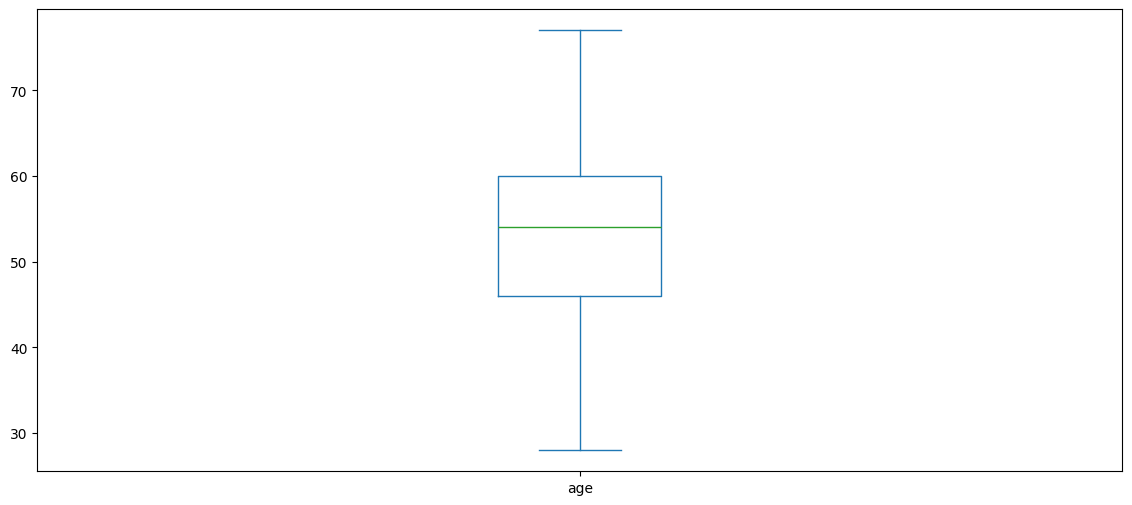

In [118]:
Hrt['age'].plot(kind='box' , vert=True, figsize=(14,6))

<BarContainer object of 1048 artists>

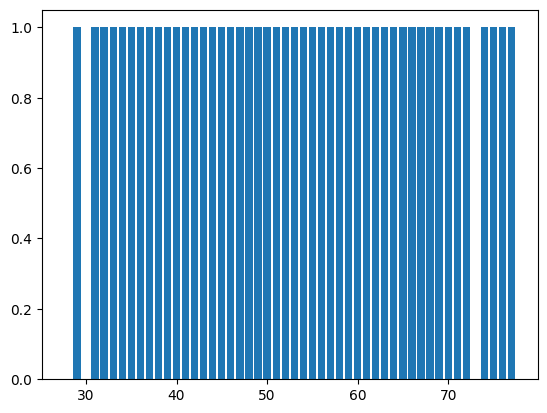

In [119]:
plt.bar(Hrt['age'],Hrt['target'])

<Axes: >

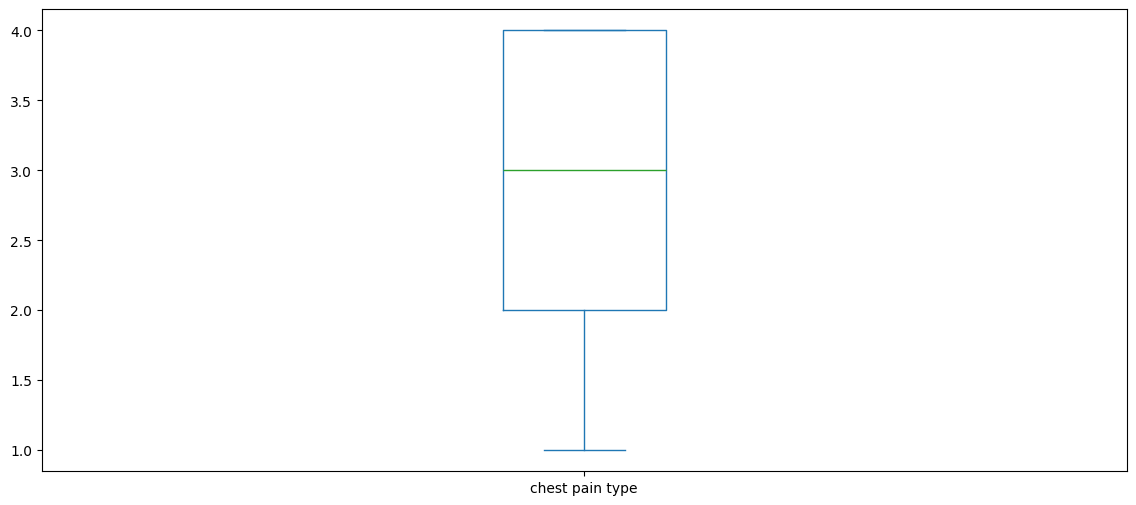

In [120]:
Hrt['chest pain type'].plot(kind='box' , vert=True, figsize=(14,6)) 

<Axes: >

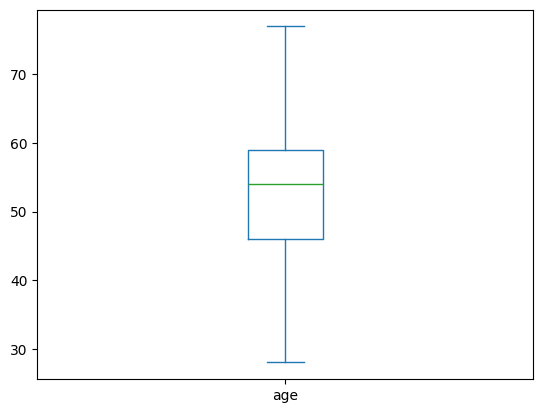

In [121]:
Male['age'].plot(kind='box')

<Axes: >

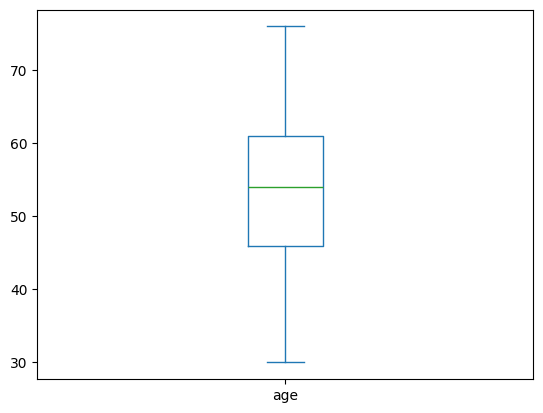

In [122]:
Female['age'].plot(kind = 'box')

In [123]:
ECG_Male

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
2,37,Male,2,130,283.0,0,1,98,0,0.0,1,0
11,58,Male,2,136,164.0,0,1,99,1,2.0,2,1
14,42,Female,3,115,211.0,0,1,137,0,0.0,1,0
26,53,Male,4,124,260.0,0,1,112,1,3.0,2,0
33,41,Male,4,130,172.0,0,1,130,0,2.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1041,52,Male,1,108,233.0,1,1,147,0,0.1,2,1
1042,64,Male,3,140,335.0,0,1,158,0,0.0,2,0
1044,44,Female,3,108,141.0,0,1,175,0,0.6,1,1
1045,52,Male,1,128,255.0,0,1,161,1,0.0,2,0


In [124]:
Angina_No_Col_High

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,Male,2,140,289.0,0,0,172,0,0.0,1,0
2,37,Male,2,130,283.0,0,1,98,0,0.0,1,0
5,39,Male,3,120,339.0,0,0,170,0,0.0,1,0
9,48,Female,2,120,284.0,0,0,120,0,0.0,1,0
15,54,Female,2,120,273.0,0,0,150,0,1.5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1027,55,Male,2,130,262.0,0,1,155,0,0.0,2,1
1032,43,Male,1,115,303.0,0,1,181,0,1.2,1,1
1034,65,Male,4,138,282.0,1,0,174,0,1.4,1,0
1042,64,Male,3,140,335.0,0,1,158,0,0.0,2,0


In [125]:
Angina_Yes_Col_High

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
23,44,Male,2,150,288.0,0,0,150,1,3.0,2,1
26,53,Male,4,124,260.0,0,1,112,1,3.0,2,0
36,65,Male,4,140,306.0,1,0,87,1,1.5,2,1
41,54,Female,3,130,294.0,0,1,100,1,0.0,2,1
45,59,Male,3,130,318.0,0,0,120,1,1.0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
991,35,Male,1,126,282.0,0,0,156,1,0.0,2,0
994,68,Male,3,180,274.0,1,0,150,1,1.6,1,0
997,51,Female,1,130,305.0,0,1,142,1,1.2,1,0
1002,41,Female,3,112,268.0,0,0,172,1,0.0,2,1


In [126]:
High_Col_Pain

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
3,48,Female,4,138,214.0,0,0,108,1,1.5,2,1
5,39,Male,3,120,339.0,0,0,170,0,0.0,1,0
8,37,Male,4,140,207.0,0,0,130,1,1.5,2,1
10,37,Female,3,130,211.0,0,0,142,0,0.0,1,0
13,49,Male,4,140,234.0,0,0,140,1,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1034,65,Male,4,138,282.0,1,0,174,0,1.4,1,0
1037,66,Female,4,150,226.0,0,1,114,0,2.6,0,1
1042,64,Male,3,140,335.0,0,1,158,0,0.0,2,0
1043,68,Female,3,120,211.0,0,0,115,0,1.5,1,1


In [127]:
Low_Col_Pain

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
1,49,Female,3,160,180.0,0,0,156,0,1.0,2,1
4,54,Male,3,150,195.0,0,0,122,0,0.0,1,0
16,38,Male,4,110,196.0,0,0,166,0,0.0,2,1
31,56,Male,3,130,167.0,0,0,114,0,0.0,1,0
33,41,Male,4,130,172.0,0,1,130,0,2.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
984,51,Male,3,110,175.0,0,1,123,0,0.6,2,1
986,46,Female,3,142,177.0,0,0,160,1,1.4,0,1
999,57,Male,3,150,168.0,0,1,174,0,1.6,2,1
1040,60,Female,3,120,178.0,1,1,96,0,0.0,2,1


In [128]:
Resting_High_HR

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
1,49,Female,3,160,180.0,0,0,156,0,1.0,2,1
2,37,Male,2,130,283.0,0,1,98,0,0.0,1,0
3,48,Female,4,138,214.0,0,0,108,1,1.5,2,1
4,54,Male,3,150,195.0,0,0,122,0,0.0,1,0
8,37,Male,4,140,207.0,0,0,130,1,1.5,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1037,66,Female,4,150,226.0,0,1,114,0,2.6,0,1
1040,60,Female,3,120,178.0,1,1,96,0,0.0,2,1
1043,68,Female,3,120,211.0,0,0,115,0,1.5,1,1
1046,59,Male,4,160,273.0,0,0,125,0,0.0,2,0


In [129]:
High_Peak_ECG

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
369,76,Male,3,104,113.0,0,2,120,0,3.5,3,1
406,57,Male,4,156,173.0,0,2,119,1,3.0,3,1
443,70,Male,4,130,322.0,0,2,109,0,2.4,2,1
452,63,Female,4,150,407.0,0,2,154,0,4.0,2,1
460,53,Male,4,140,203.0,1,2,155,1,3.1,3,1
463,67,Male,4,120,229.0,0,2,129,1,2.6,2,1
471,58,Male,3,112,230.0,0,2,165,0,2.5,2,1
474,66,Male,4,160,228.0,0,2,138,0,2.3,1,0
476,59,Male,4,170,326.0,0,2,140,1,3.4,3,1
499,61,Male,4,138,166.0,0,2,125,1,3.6,2,1
